In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
btc = pd.read_csv("btc_usd_daily.csv")
realized = pd.read_csv("daily_realized.csv")
fear_greed = pd.read_csv("fear_greed_daily.csv")
gtrend = pd.read_csv("google_trends_bitcoin_daily.csv")
blockchain = pd.read_csv("blockchain_data.csv")
macro = pd.read_csv("macro_indicators_data_2016_2026.csv")

In [4]:
btc["date"] = pd.to_datetime(btc["date"])
btc

,date,open,high,low,close,volume
0,2016-01-31,378.46,382.50,365.00,367.95,5506.776813
1,2016-02-01,367.89,379.00,366.26,371.33,7931.229229
2,2016-02-02,371.33,374.41,371.17,372.93,6856.218158
3,2016-02-03,372.93,373.01,365.63,368.87,7147.956573
4,2016-02-04,368.87,390.63,368.74,387.99,8887.757232
...,...,...,...,...,...,...
3650,2026-01-28,89116.96,90476.81,88706.32,89162.40,6636.136099
3651,2026-01-29,89162.40,89210.16,83216.21,84513.20,14860.940293
3652,2026-01-30,84513.19,84599.00,81000.12,84110.99,15232.811992
3653,2026-01-31,84110.99,84138.00,75644.15,78648.00,14855.073443


<Axes: >

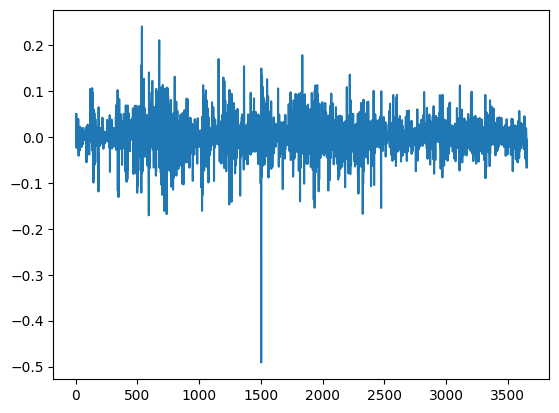

In [5]:
btc["log_return"] = np.log(btc["close"]).diff()

btc["log_return"].plot()

In [6]:
btc["proxy_realised_variance"] = btc["log_return"]**2
btc["proxy_realised_volatility"] = np.abs(btc["log_return"])

In [7]:
realized = realized.rename(columns={"Unnamed: 0": "date"})
realized["date"] = pd.to_datetime(realized["date"])
realized

,date,realized_variance,realized_volatility
0,2016-02-01,0.000424,0.020584
1,2016-02-02,0.000075,0.008650
2,2016-02-03,0.000105,0.010256
3,2016-02-04,0.000988,0.031438
4,2016-02-05,0.000221,0.014855
...,...,...,...
3649,2026-01-28,0.000319,0.017847
3650,2026-01-29,0.001190,0.034490
3651,2026-01-30,0.000855,0.029246
3652,2026-01-31,0.000998,0.031598


In [8]:
df = btc.merge(realized, on="date", how="inner")

print(len(btc))
print(len(realized))
print(len(df))
df.isna().sum()

3655
3654
3654


date                         0
open                         0
high                         0
low                          0
close                        0
volume                       0
log_return                   0
proxy_realised_variance      0
proxy_realised_volatility    0
realized_variance            0
realized_volatility          0
dtype: int64

In [9]:
df

,date,open,high,low,close,volume,log_return,proxy_realised_variance,proxy_realised_volatility,realized_variance,realized_volatility
0,2016-02-01,367.89,379.00,366.26,371.33,7931.229229,0.009144,8.361449e-05,0.009144,0.000424,0.020584
1,2016-02-02,371.33,374.41,371.17,372.93,6856.218158,0.004300,1.848638e-05,0.004300,0.000075,0.008650
2,2016-02-03,372.93,373.01,365.63,368.87,7147.956573,-0.010946,1.198249e-04,0.010946,0.000105,0.010256
3,2016-02-04,368.87,390.63,368.74,387.99,8887.757232,0.050535,2.553815e-03,0.050535,0.000988,0.031438
4,2016-02-05,387.99,389.36,382.99,384.50,7443.929332,-0.009036,8.164527e-05,0.009036,0.000221,0.014855
...,...,...,...,...,...,...,...,...,...,...,...
3649,2026-01-28,89116.96,90476.81,88706.32,89162.40,6636.136099,0.000510,2.598571e-07,0.000510,0.000319,0.017847
3650,2026-01-29,89162.40,89210.16,83216.21,84513.20,14860.940293,-0.053552,2.867784e-03,0.053552,0.001190,0.034490
3651,2026-01-30,84513.19,84599.00,81000.12,84110.99,15232.811992,-0.004770,2.275766e-05,0.004770,0.000855,0.029246
3652,2026-01-31,84110.99,84138.00,75644.15,78648.00,14855.073443,-0.067155,4.509799e-03,0.067155,0.000998,0.031598


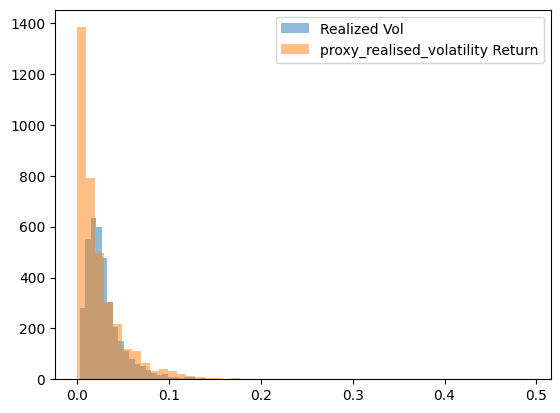

In [10]:
plt.hist(df["realized_volatility"], bins=50, alpha=0.5, label="Realized Vol")
plt.hist(df["proxy_realised_volatility"], bins=50, alpha=0.5, label="proxy_realised_volatility Return")
plt.legend()
plt.show()

In [11]:
fear_greed["timestamp"] = pd.to_datetime(fear_greed["timestamp"])
fear_greed = fear_greed.rename(columns={"timestamp": "date"})

fear_greed

,date,fng,value_classification,fng_change
0,2018-02-01,30,Fear,NaN
1,2018-02-02,15,Extreme Fear,-15.0
2,2018-02-03,40,Fear,25.0
3,2018-02-04,24,Extreme Fear,-16.0
4,2018-02-05,11,Extreme Fear,-13.0
...,...,...,...,...
2943,2026-02-26,11,Extreme Fear,0.0
2944,2026-02-27,13,Extreme Fear,2.0
2945,2026-02-28,11,Extreme Fear,-2.0
2946,2026-03-01,14,Extreme Fear,3.0


In [12]:
print(len(df))
df = df.merge(fear_greed, on="date", how="left")

print(len(fear_greed))
print(len(df))
df.isna().sum()

3654
2948
3654


date                           0
open                           0
high                           0
low                            0
close                          0
volume                         0
log_return                     0
proxy_realised_variance        0
proxy_realised_volatility      0
realized_variance              0
realized_volatility            0
fng                          735
value_classification         735
fng_change                   736
dtype: int64

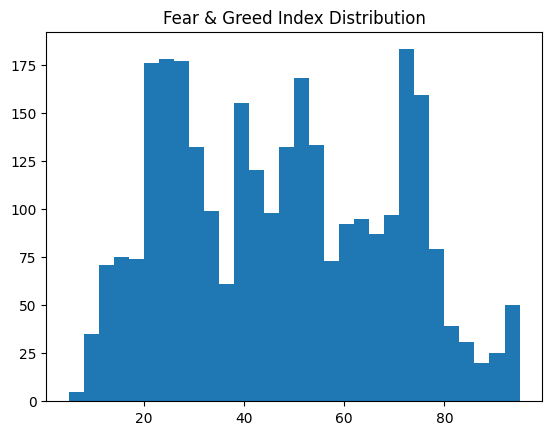

In [13]:
plt.hist(df["fng"].dropna(), bins=30)
plt.title("Fear & Greed Index Distribution")
plt.show()

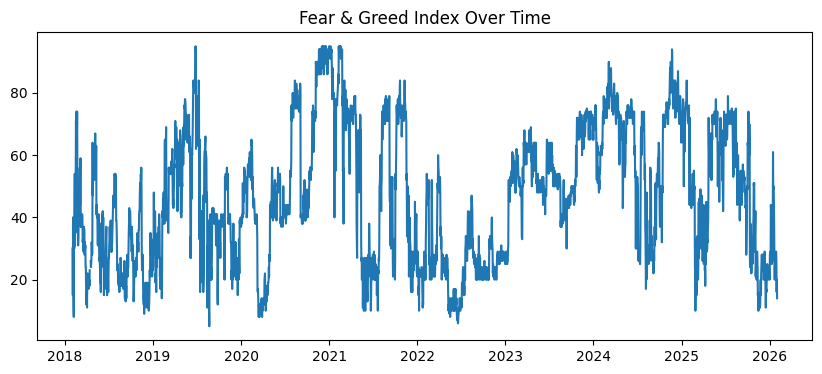

In [14]:
plt.figure(figsize=(10,4))
plt.plot(df["date"], df["fng"])
plt.title("Fear & Greed Index Over Time")
plt.show()

In [15]:
gtrend = gtrend[[
    "date",
    "google_trend",
    "gtrend_change",
    "gtrend_pct_change"
]]

gtrend["date"] = pd.to_datetime(gtrend["date"])

gtrend

,date,google_trend,gtrend_change,gtrend_pct_change
0,2016-02-01,2.58,0.60,0.303030
1,2016-02-02,2.46,-0.12,-0.046512
2,2016-02-03,2.43,-0.03,-0.012195
3,2016-02-04,2.55,0.12,0.049383
4,2016-02-05,2.43,-0.12,-0.047059
...,...,...,...,...
3649,2026-01-28,13.68,-0.96,-0.065574
3650,2026-01-29,18.24,4.56,0.333333
3651,2026-01-30,21.36,3.12,0.171053
3652,2026-01-31,24.00,2.64,0.123596


In [16]:
print(len(df))
df = df.merge(gtrend, on="date", how="left")

print(len(gtrend))
print(len(df))
df.isna().sum()

3654
3654
3654


date                           0
open                           0
high                           0
low                            0
close                          0
volume                         0
log_return                     0
proxy_realised_variance        0
proxy_realised_volatility      0
realized_variance              0
realized_volatility            0
fng                          735
value_classification         735
fng_change                   736
google_trend                   0
gtrend_change                  0
gtrend_pct_change              0
dtype: int64

In [17]:
df[["google_trend","gtrend_change","gtrend_pct_change"]].describe()

,google_trend,gtrend_change,gtrend_pct_change
count,3654.000000,3654.000000,3654.000000
mean,13.804472,0.004395,0.015105
std,8.922818,3.487567,0.192562
min,1.160000,-40.000000,-0.680000
25%,8.190000,-0.960000,-0.079500
50%,12.420000,-0.100000,-0.014085
75%,17.215000,0.680000,0.066667
max,100.000000,49.000000,2.760000


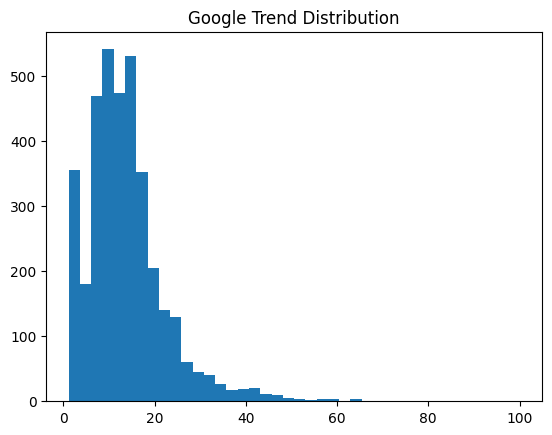

In [18]:
plt.hist(df["google_trend"].dropna(), bins=40)
plt.title("Google Trend Distribution")
plt.show()

In [19]:
macro = macro.rename(columns={"Date": "date"})
macro["date"] = pd.to_datetime(macro["date"])

macro

,date,gold_close,gold_vol,silver_close,silver_vol,brent_close,brent_vol,dji_close,dji_vol,spx_close,spx_vol,rut_close,rut_vol,nasdaq_close,nasdaq_vol,usdcny_close,usdeur_close,vix_close
0,2016-02-01,1127.900024,1682.0,14.329000,9.0,34.689999,36878.0,16449.179688,114450000.0,1939.380005,4.322530e+09,1032.390015,4.322530e+09,4620.370117,1.983340e+09,6.5661,0.92371,19.980000
1,2016-02-02,1127.300049,1230.0,14.276000,2.0,32.720001,37956.0,16153.540039,126210000.0,1903.030029,4.463190e+09,1008.840027,4.463190e+09,4516.950195,2.185180e+09,6.5684,0.91766,21.980000
2,2016-02-03,1141.300049,1630.0,14.720000,47.0,35.040001,51237.0,16336.660156,141870000.0,1912.530029,5.172950e+09,1010.299988,5.172950e+09,4504.240234,2.466190e+09,6.5698,0.91558,21.650000
3,2016-02-04,1157.599976,771.0,14.836000,23.0,34.459999,37559.0,16416.580078,131490000.0,1915.449951,5.193320e+09,1014.789978,5.193320e+09,4509.560059,2.200930e+09,6.5670,0.90163,21.840000
4,2016-02-05,1157.800049,877.0,14.764000,7.0,34.060001,34903.0,16204.969727,139010000.0,1880.050049,4.929940e+09,985.619995,4.929940e+09,4363.140137,2.489280e+09,6.5548,0.89286,23.379999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,2026-01-26,5079.700195,180.0,115.080002,537.0,65.589996,25795.0,49412.398438,454370000.0,6950.229980,4.968050e+09,2659.669922,4.968050e+09,23601.359375,7.505250e+09,6.9726,0.84328,16.150000
2511,2026-01-27,5079.899902,34.0,105.523003,131.0,67.570000,34327.0,49003.410156,533780000.0,6978.600098,5.331720e+09,2666.699951,5.331720e+09,23817.099609,8.026050e+09,6.9542,0.84200,16.350000
2512,2026-01-28,5301.600098,112054.0,113.111000,1436.0,68.400002,23555.0,49015.601562,470990000.0,6978.029785,5.507670e+09,2653.550049,5.507670e+09,23857.449219,8.151580e+09,6.9545,0.83211,16.350000
2513,2026-01-29,5318.399902,23709.0,114.037003,1261.0,70.709999,26980.0,49071.558594,693040000.0,6969.009766,6.877780e+09,2654.780029,6.877780e+09,23685.119141,8.782210e+09,6.9545,0.83488,16.879999


In [20]:
print(len(df))
df = df.merge(macro, on="date", how="left")

print(len(macro))
print(len(df))
df.isna().sum()

3654
2515
3654


date                            0
open                            0
high                            0
low                             0
close                           0
volume                          0
log_return                      0
proxy_realised_variance         0
proxy_realised_volatility       0
realized_variance               0
realized_volatility             0
fng                           735
value_classification          735
fng_change                    736
google_trend                    0
gtrend_change                   0
gtrend_pct_change               0
gold_close                   1142
gold_vol                     1142
silver_close                 1142
silver_vol                   1142
brent_close                  1141
brent_vol                    1141
dji_close                    1139
dji_vol                      1139
spx_close                    1139
spx_vol                      1139
rut_close                    1139
rut_vol                      1139
nasdaq_close  

In [21]:
df1 = df.copy()
df1["weekday"] = df1["date"].dt.day_name()
df1[df1["vix_close"].isna()]["weekday"].value_counts()

weekday
Saturday     522
Sunday       522
Monday        53
Thursday      16
Friday        15
Wednesday      7
Tuesday        4
Name: count, dtype: int64

In [22]:
macro_cols = [
    "gold_close","gold_vol","silver_close","silver_vol",
    "brent_close","brent_vol","dji_close","dji_vol",
    "spx_close","spx_vol","rut_close","rut_vol",
    "nasdaq_close","nasdaq_vol","usdcny_close","usdeur_close",
    "vix_close"
]

df[macro_cols] = df[macro_cols].ffill()

In [23]:
df.isna().sum()

date                           0
open                           0
high                           0
low                            0
close                          0
volume                         0
log_return                     0
proxy_realised_variance        0
proxy_realised_volatility      0
realized_variance              0
realized_volatility            0
fng                          735
value_classification         735
fng_change                   736
google_trend                   0
gtrend_change                  0
gtrend_pct_change              0
gold_close                     0
gold_vol                       0
silver_close                   0
silver_vol                     0
brent_close                    0
brent_vol                      0
dji_close                      0
dji_vol                        0
spx_close                      0
spx_vol                        0
rut_close                      0
rut_vol                        0
nasdaq_close                   0
nasdaq_vol

In [24]:
df

,date,open,high,low,close,volume,log_return,proxy_realised_variance,proxy_realised_volatility,realized_variance,...,dji_vol,spx_close,spx_vol,rut_close,rut_vol,nasdaq_close,nasdaq_vol,usdcny_close,usdeur_close,vix_close
0,2016-02-01,367.89,379.00,366.26,371.33,7931.229229,0.009144,8.361449e-05,0.009144,0.000424,...,114450000.0,1939.380005,4.322530e+09,1032.390015,4.322530e+09,4620.370117,1.983340e+09,6.5661,0.92371,19.980000
1,2016-02-02,371.33,374.41,371.17,372.93,6856.218158,0.004300,1.848638e-05,0.004300,0.000075,...,126210000.0,1903.030029,4.463190e+09,1008.840027,4.463190e+09,4516.950195,2.185180e+09,6.5684,0.91766,21.980000
2,2016-02-03,372.93,373.01,365.63,368.87,7147.956573,-0.010946,1.198249e-04,0.010946,0.000105,...,141870000.0,1912.530029,5.172950e+09,1010.299988,5.172950e+09,4504.240234,2.466190e+09,6.5698,0.91558,21.650000
3,2016-02-04,368.87,390.63,368.74,387.99,8887.757232,0.050535,2.553815e-03,0.050535,0.000988,...,131490000.0,1915.449951,5.193320e+09,1014.789978,5.193320e+09,4509.560059,2.200930e+09,6.5670,0.90163,21.840000
4,2016-02-05,387.99,389.36,382.99,384.50,7443.929332,-0.009036,8.164527e-05,0.009036,0.000221,...,139010000.0,1880.050049,4.929940e+09,985.619995,4.929940e+09,4363.140137,2.489280e+09,6.5548,0.89286,23.379999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,2026-01-28,89116.96,90476.81,88706.32,89162.40,6636.136099,0.000510,2.598571e-07,0.000510,0.000319,...,470990000.0,6978.029785,5.507670e+09,2653.550049,5.507670e+09,23857.449219,8.151580e+09,6.9545,0.83211,16.350000
3650,2026-01-29,89162.40,89210.16,83216.21,84513.20,14860.940293,-0.053552,2.867784e-03,0.053552,0.001190,...,693040000.0,6969.009766,6.877780e+09,2654.780029,6.877780e+09,23685.119141,8.782210e+09,6.9545,0.83488,16.879999
3651,2026-01-30,84513.19,84599.00,81000.12,84110.99,15232.811992,-0.004770,2.275766e-05,0.004770,0.000855,...,761990000.0,6939.029785,6.697340e+09,2613.739990,6.697340e+09,23461.820312,9.255930e+09,6.9480,0.83572,17.440001
3652,2026-01-31,84110.99,84138.00,75644.15,78648.00,14855.073443,-0.067155,4.509799e-03,0.067155,0.000998,...,761990000.0,6939.029785,6.697340e+09,2613.739990,6.697340e+09,23461.820312,9.255930e+09,6.9480,0.83572,17.440001


In [25]:
blockchain = blockchain[["date","hash-rate","difficulty","median-confirmation-time",
                         "blockchain_log_n_transactions","blockchain_log_transaction_fee_usd","blockchain_log_n_unique_addresses",
                         "blockchain_log_mempool_count","blockchain_log_transaction_volume+usd",
                         "blockchain_diff_log_n_transactions", "blockchain_diff_log_transaction_fee_usd", 
                         "blockchain_diff_log_n_unique_addresses","blockchain_diff_log_transaction_volume_usd"
]]

blockchain["date"] = pd.to_datetime(blockchain["date"])

In [26]:
print(len(df))
df = df.merge(blockchain, on="date", how="left")

print(len(blockchain))
print(len(df))
df.isna().sum()

3654
3655
3654


date                                            0
open                                            0
high                                            0
low                                             0
close                                           0
volume                                          0
log_return                                      0
proxy_realised_variance                         0
proxy_realised_volatility                       0
realized_variance                               0
realized_volatility                             0
fng                                           735
value_classification                          735
fng_change                                    736
google_trend                                    0
gtrend_change                                   0
gtrend_pct_change                               0
gold_close                                      0
gold_vol                                        0
silver_close                                    0


In [27]:
df["log_volume"] = np.log(df["volume"] + 1)

**7- and 30- rolling mean of volatility**

In [28]:
df["RV_1"] = df["realized_volatility"] # this one is for prev day volatiltiy
df["RV_7"] = df["realized_volatility"].rolling(7).mean()
df["RV_30"] = df["realized_volatility"].rolling(30).mean()

In [29]:
df["target"] = df["realized_volatility"].shift(-1)

In [ ]:
# df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'log_return',
       'proxy_realised_variance', 'proxy_realised_volatility',
       'realized_variance', 'realized_volatility', 'fng',
       'value_classification', 'fng_change', 'google_trend', 'gtrend_change',
       'gtrend_pct_change', 'gold_close', 'gold_vol', 'silver_close',
       'silver_vol', 'brent_close', 'brent_vol', 'dji_close', 'dji_vol',
       'spx_close', 'spx_vol', 'rut_close', 'rut_vol', 'nasdaq_close',
       'nasdaq_vol', 'usdcny_close', 'usdeur_close', 'vix_close', 'hash-rate',
       'difficulty', 'median-confirmation-time',
       'blockchain_log_n_transactions', 'blockchain_log_transaction_fee_usd',
       'blockchain_log_n_unique_addresses', 'blockchain_log_mempool_count',
       'blockchain_log_transaction_volume+usd',
       'blockchain_diff_log_n_transactions',
       'blockchain_diff_log_transaction_fee_usd',
       'blockchain_diff_log_n_unique_addresses',
       'blockchain_diff_log_transaction_vo

In [ ]:
# df

,date,open,high,low,close,volume,log_return,proxy_realised_variance,proxy_realised_volatility,realized_variance,...,blockchain_log_transaction_volume+usd,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,RV_1,RV_7,RV_30,target
0,2016-02-01,367.89,379.00,366.26,371.33,7931.229229,0.009144,8.361449e-05,0.009144,0.000424,...,19.045754,0.233729,0.463983,0.019566,0.589070,8.978689,0.020584,NaN,NaN,0.008650
1,2016-02-02,371.33,374.41,371.17,372.93,6856.218158,0.004300,1.848638e-05,0.004300,0.000075,...,18.940304,0.083320,0.108519,0.173418,-0.105450,8.833057,0.008650,NaN,NaN,0.010256
2,2016-02-03,372.93,373.01,365.63,368.87,7147.956573,-0.010946,1.198249e-04,0.010946,0.000105,...,18.567064,-0.234343,-0.290071,-0.282119,-0.373240,8.874722,0.010256,NaN,NaN,0.031438
3,2016-02-04,368.87,390.63,368.74,387.99,8887.757232,0.050535,2.553815e-03,0.050535,0.000988,...,18.798095,0.048171,-0.157233,0.064870,0.231030,9.092543,0.031438,NaN,NaN,0.014855
4,2016-02-05,387.99,389.36,382.99,384.50,7443.929332,-0.009036,8.164527e-05,0.009036,0.000221,...,18.961049,0.116650,0.131097,0.066352,0.162954,8.915288,0.014855,NaN,NaN,0.021939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,2026-01-28,89116.96,90476.81,88706.32,89162.40,6636.136099,0.000510,2.598571e-07,0.000510,0.000319,...,22.885848,-0.075153,0.240570,0.021306,0.359595,8.800436,0.017847,0.015813,0.016421,0.034490
3650,2026-01-29,89162.40,89210.16,83216.21,84513.20,14860.940293,-0.053552,2.867784e-03,0.053552,0.001190,...,23.004533,0.243422,-0.024924,0.071430,0.118684,9.606559,0.034490,0.018706,0.017114,0.029246
3651,2026-01-30,84513.19,84599.00,81000.12,84110.99,15232.811992,-0.004770,2.275766e-05,0.004770,0.000855,...,23.420703,-0.118552,0.068726,0.107636,0.416170,9.631273,0.029246,0.020428,0.017663,0.031598
3652,2026-01-31,84110.99,84138.00,75644.15,78648.00,14855.073443,-0.067155,4.509799e-03,0.067155,0.000998,...,22.873796,0.062615,-0.051867,-0.096210,-0.546907,9.606164,0.031598,0.024188,0.018443,0.025307


In [ ]:
# df.to_csv("df.csv")

In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
cols_to_check = [
    "gold_close", "gold_vol",
    "silver_close", "silver_vol",
    "brent_close", "brent_vol",
    "dji_close", "dji_vol",
    "spx_close", "spx_vol",
    "rut_close", "rut_vol",
    "nasdaq_close", "nasdaq_vol",
    "usdcny_close", "usdeur_close",
    "vix_close"
]

(df[cols_to_check] == 0).sum()

In [ ]:
vol_cols = [
    "gold_vol",
    "silver_vol",
    "brent_vol",
    "spx_vol",
    "rut_vol"
]

# fill forward for exogoneous volume columns

for col in vol_cols:
    df.loc[df[col] == 0, col] = np.nan
df[vol_cols] = df[vol_cols].ffill()

(df[cols_to_check] == 0).sum()

In [ ]:
# drop irrelevant columns
cols_to_drop = ['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume',
                'proxy_realised_variance', 'proxy_realised_volatility', 
                'fng', 'value_classification', 'google_trend', 'gtrend_change',
                'RV_1', 'RV_7', 'RV_30', "blockchain_log_n_transactions","blockchain_log_transaction_fee_usd","blockchain_log_n_unique_addresses",
                "blockchain_log_transaction_volume+usd"]
df = df.drop(columns=cols_to_drop)

In [ ]:
# check for na values
df.isna().sum()

df[df["blockchain_log_mempool_count"].isna()][["date"]]

# na values are in contiguous time block so safe to drop them 
df = df.dropna(subset=["blockchain_log_mempool_count"])

# check for na values again
df.isna().sum()

In [ ]:
df[df["fng_change"].isna()][["date"]]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(df["date"], df["fng_change"].isna())
plt.title("NA locations over time")
plt.show()

In [ ]:
# remove fng column for now due to problematic na values
df = df.drop(columns=["fng_change"])

In [ ]:
# convert raw levels to returns

price_cols = [
    "gold_close",
    "silver_close",
    "brent_close",
    "dji_close",
    "spx_close",
    "rut_close",
    "nasdaq_close",
    "usdcny_close",
    "usdeur_close"
]

vol_cols = [
    "gold_vol",
    "silver_vol",
    "brent_vol",
    "dji_vol",
    "spx_vol",
    "rut_vol",
    "nasdaq_vol",
    "vix_close"
]

meta_cols = [
    "hash-rate",
    "difficulty",
    "median-confirmation-time",
    "blockchain_log_mempool_count"
]

for col in price_cols:
    df[f"{col}_ret"] = np.log(df[col]).diff()

for col in vol_cols:
    df[f"{col}_chg"] = np.log(df[col]).diff()

for col in meta_cols:
    df[f"{col}_chg"] = np.log(df[col]).diff()

# drop original price and volume columns
df = df.drop(columns=price_cols + vol_cols + meta_cols)

# drop first row for which returns are na
df = df.dropna()

df = df.rename(columns=lambda x: x.replace("_vol_", "_volume_"))

df.head()

In [ ]:
# Summary statistics
df2 = df.copy()
df2['log_realized_variance'] = np.log(df2['realized_variance'])
df2 = df2.drop(columns=['date', 'realized_volatility','realized_variance'])

In [ ]:
summary = df2.describe().loc[['mean', 'std', 'min', 'max']].T
summary = summary.round(3)
summary

In [ ]:
# export to csv
#df.to_csv('df_clean.csv', index=False)